# Valutazione e analisi

## 1. Setup

In [ ]:
import sys

if ".venv" not in sys.executable.lower():
    print("!" * 68)
    print("KERNEL SBAGLIATO")
    print("  stai usando:", sys.executable)
    raise SystemExit("kernel errato")

import os, time, subprocess, glob
from pathlib import Path
import pandas as pd
import psutil
from IPython.display import clear_output, display

CODICE = Path.cwd()
os.chdir(CODICE)
PY = str(CODICE / ".venv" / "Scripts" / "python.exe")

import PCNAME
PC = PCNAME.name
RESULTS = CODICE / ("csv_" + PC) / PC / ("federated_grid_search_results_" + PC + ".csv")
LOGFILE = CODICE / "pesi_output.log"

RUN = globals().get("RUN", None)

def risultati():
    """Le 216 esecuzioni della griglia: 108 in chiaro + 108 cifrate."""
    if not RESULTS.exists():
        return pd.DataFrame()
    try:
        d = pd.read_csv(RESULTS)
    except Exception as e:
        print("CSV illeggibile:", e)
        return pd.DataFrame()
    return d[d["global_epoch"] == 20] if "global_epoch" in d.columns else pd.DataFrame()

def pesi_salvati():
    trovati = []
    for schema in ("csv*/runs/*_weights.npz", "csv*/*/runs/*_weights.npz"):
        trovati.extend(Path(p) for p in glob.glob(schema))
    return sorted(set(trovati))

print("kernel OK:", sys.executable)
r = risultati()
ch = r[r.encryption_mode == "no_encryption"] if len(r) else r
ci = r[r.encryption_mode != "no_encryption"] if len(r) else r
print(f"esecuzioni in chiaro : {len(ch)}")
print(f"esecuzioni cifrate   : {len(ci)}")
print(f"file di pesi salvati : {len(pesi_salvati())}")

kernel OK: c:\Progetti\FL\Codice\.venv\Scripts\python.exe
esecuzioni in chiaro : 108
esecuzioni cifrate   : 108
file di pesi salvati : 4


## 2. Stato

In [10]:
r = risultati()
ch = r[r.encryption_mode == "no_encryption"]
ci = r[r.encryption_mode != "no_encryption"]

print(f"IN CHIARO  {len(ch)} esecuzioni")
if len(ch):
    m = ch.loc[ch["best_f1"].idxmax()]
    print(f"  migliore: {m.model_name}, head {m.num_custom_layers}, {m.aggregation_algorithm}, "
          f"lr {m.learning_rate}, {m.num_clients} client -> F1 {m.best_f1:.4f}")
    print(f"  divergenze (F1 < 0.60): {(ch['best_f1'] < 0.60).sum()}")

print()
print(f"CIFRATE    {len(ci)} esecuzioni")
if len(ci):
    print(f"  modelli coperti: {dict(ci.model_name.value_counts())}")
    print("  nota: la coda non ha raggiunto DeiT-Tiny, il confronto cifrato e' asimmetrico")

print()
p = pesi_salvati()
if p:
    print(f"PESI       {len(p)} file")
    for x in p:
        print("  ", x)
else:
    print("PESI       nessuno - esegui la cella 3")

for nome in ("road_signs_binary", "road_signs_test"):
    d = CODICE / "dataset" / nome
    if d.is_dir():
        n = {c.name: len(list(c.glob("*.jpg"))) for c in d.iterdir() if c.is_dir()}
        print(f"\n{nome}: {sum(n.values())} ritagli {n}")

IN CHIARO  108 esecuzioni
  migliore: DeiT-Tiny, head 4, FedProx, lr 0.001, 10 client -> F1 0.9634
  divergenze (F1 < 0.60): 7

CIFRATE    108 esecuzioni
  modelli coperti: {'ResNet18': 54, 'DeiT-Tiny': 54}
  nota: la coda non ha raggiunto DeiT-Tiny, il confronto cifrato e' asimmetrico

PESI       4 file
   csv_best_DESKTOP-APC2VEU\runs\20260903-130946_road_signs_binary_worker_0_weights.npz
   csv_enc2_DESKTOP-APC2VEU\runs\20260906-172554_road_signs_binary_worker_1_weights.npz
   csv_enc2_DESKTOP-APC2VEU\runs\20260906-172615_road_signs_binary_worker_2_weights.npz
   csv_enc2_DESKTOP-APC2VEU\runs\20260906-172617_road_signs_binary_worker_0_weights.npz

road_signs_binary: 7100 ritagli {'damaged': 4112, 'healthy': 2988}

road_signs_test: 957 ritagli {'damaged': 505, 'healthy': 452}


## 3. Rigenera i pesi del modello migliore

Riesegue la sola configurazione vincente (DeiT-Tiny, head 4, FedProx, lr 0.001,
10 client) con la persistenza dei pesi ora attiva. Circa 10 minuti.

Usa un percorso di risultati dedicato, altrimenti la deduplica la salterebbe.

In [11]:
if RUN is not None and RUN.poll() is None:
    print(f"Gia' in esecuzione (PID {RUN.pid}).")
else:
    env = os.environ.copy()
    env["FL_CONFIG"] = "best_config.json"
    env["FL_WORKERS"] = "1"
    env["PYTHONUNBUFFERED"] = "1"
    RUN = subprocess.Popen(
        [PY, "-u", "federated_grid_search.py"],
        env=env, cwd=str(CODICE),
        stdout=open(LOGFILE, "w", encoding="utf-8", errors="replace"),
        stderr=subprocess.STDOUT,
        creationflags=subprocess.CREATE_NEW_PROCESS_GROUP,
    )
    print(f"Avviata (PID {RUN.pid}). Segui con la cella 4.")

Avviata (PID 29016). Segui con la cella 4.


## 4. Avanzamento

Termina da sola quando i pesi compaiono su disco.

In [12]:
CICLI, OGNI = 80, 15

def gpu():
    try:
        raw = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=utilization.gpu,power.draw,temperature.gpu",
             "--format=csv,noheader,nounits"], text=True, timeout=10).strip().splitlines()[0]
        u, w, t = (x.strip() for x in raw.split(","))
        return f"{float(u):3.0f}%  {float(w):5.1f} W  {float(t):3.0f} C"
    except Exception:
        return "non disponibile"

t0 = time.time()
try:
    for _ in range(CICLI):
        p = pesi_salvati()
        attiva = RUN is not None and RUN.poll() is None
        clear_output(wait=True)
        print("=" * 58)
        print("  RIGENERAZIONE DEI PESI")
        print("=" * 58)
        print(f"  trascorso     : {int(time.time()-t0)//60} min {int(time.time()-t0)%60:02d} s")
        print(f"  processo      : {'in corso' if attiva else 'terminato'}")
        print(f"  file di pesi  : {len(p)}")
        print(f"  GPU  {gpu()}")
        print(f"  CPU  {psutil.cpu_percent(interval=0.5):3.0f}%")
        if LOGFILE.exists():
            righe = [x for x in LOGFILE.read_text(encoding="utf-8", errors="replace").splitlines()
                     if x.strip() and not any(k in x for k in
                        ("Engine.IO", "Namespace", "Emitting", "Received event"))]
            if righe:
                print()
                print("  ultime righe del log")
                for x in righe[-4:]:
                    print("   ", x[:96])
        if p:
            print()
            print("  PESI SALVATI - passa alla cella 5")
            break
        if not attiva:
            print()
            print("  Processo terminato senza produrre pesi: controlla pesi_output.log")
            break
        time.sleep(OGNI)
except KeyboardInterrupt:
    print("\nMonitoraggio interrotto. L'esecuzione continua.")

  RIGENERAZIONE DEI PESI
  trascorso     : 0 min 00 s
  processo      : in corso
  file di pesi  : 4
  GPU    1%   16.6 W   40 C
  CPU    8%

  PESI SALVATI - passa alla cella 5


## 5. Valutazione sul test set

I 957 ritagli tenuti da parte, mai visti durante l'addestramento e deduplicati
rispetto al pool, comprese le copie speculari.

In [13]:
esito = subprocess.run([PY, "-u", "evaluate_test.py"],
                       capture_output=True, text=True, cwd=str(CODICE))
print(esito.stdout)
if esito.returncode != 0:
    print(esito.stderr[-2000:])

  20260903-130946_road_signs_binary_worker_0_weights.npz
Initializing model: DeiT-Tiny
Freezing pre-trained DeiT-Tiny layers. Only the custom classifier will be trained.
  modello        : DeiT-Tiny, head 4 layer
  configurazione : FedProx, lr 0.001, 10 client, round migliore 19

                    validazione       test    scarto
  --------------------------------------------------
  F1                     0.9564     0.9268   -0.0296
  accuracy                          0.9269
  precision                         0.9270
  recall                            0.9269

  matrice di confusione (957 campioni)
                    -> damaged    -> healthy
  damaged                  475            30
  healthy                   40           412

  damaged        475/505 corretti (94.1%)
  healthy        412/452 corretti (91.2%)




## 6. Tabelle

In [14]:
r = risultati()
r["divergenza"] = r["best_f1"] < 0.60
st = r[r["learning_rate"] != 0.01]      # regime stabile
hi = r[r["learning_rate"] == 0.01]      # regime instabile

print(f"TABELLA 1 - Copertura ({len(r)} esecuzioni)")
display(pd.crosstab(r.model_name, r.encryption_mode, margins=True, margins_name="TOTALE"))

print("TABELLA 2 - Confronto fra backbone, per modalita'")
display(r.groupby(["encryption_mode", "model_name"]).agg(
    esecuzioni=("best_f1", "size"), F1_medio=("best_f1", "mean"),
    F1_max=("best_f1", "max"), dev_std=("best_f1", "std"),
    divergenze=("divergenza", "sum")).round(4))

print("TABELLA 3 - Regime stabile, per backbone e profondita' della testa")
display(st.groupby(["encryption_mode", "model_name", "num_custom_layers"]).agg(
    esecuzioni=("best_f1", "size"), F1_medio=("best_f1", "mean"),
    F1_max=("best_f1", "max"), dev_std=("best_f1", "std")).round(4))

print("TABELLA 4 - Profondita' della testa: confronto appaiato nel regime stabile")
K = ["model_name", "encryption_mode", "aggregation_algorithm", "learning_rate", "num_clients"]
p2 = st[st.num_custom_layers == 2].merge(st[st.num_custom_layers == 4], on=K,
                                         suffixes=("_h2", "_h4"))
p2["testa4_meno_testa2"] = p2.best_f1_h4 - p2.best_f1_h2
display(p2.groupby(["model_name", "encryption_mode"]).agg(
    coppie=("testa4_meno_testa2", "size"),
    differenza_media=("testa4_meno_testa2", "mean"),
    dev_std=("testa4_meno_testa2", "std")).round(5))

print("TABELLA 5 - Divergenze a lr 0.01, per backbone e profondita'")
display(hi.groupby(["model_name", "num_custom_layers"]).agg(
    esecuzioni=("divergenza", "size"), divergenze=("divergenza", "sum")))

print("TABELLA 6 - Algoritmi di aggregazione a lr 0.01")
display(hi.groupby("aggregation_algorithm").agg(
    esecuzioni=("best_f1", "size"), F1_medio=("best_f1", "mean"),
    F1_min=("best_f1", "min"), divergenze=("divergenza", "sum")).round(4))

print("TABELLA 7 - Migliori dieci configurazioni")
display(r.nlargest(10, "best_f1")[
    ["model_name", "num_custom_layers", "aggregation_algorithm", "learning_rate",
     "num_clients", "encryption_mode", "best_round", "best_f1"]].round(4))

TABELLA 1 - Copertura (216 esecuzioni)


encryption_mode,direct_encrypted_update,no_encryption,TOTALE
model_name,,,
DeiT-Tiny,54,54,108
ResNet18,54,54,108
TOTALE,108,108,216


TABELLA 2 - Confronto fra backbone, per modalita'


esecuzioni  F1_medio  F1_max  dev_std  \
encryption_mode         model_name                                          
direct_encrypted_update DeiT-Tiny           54    0.9332  0.9607   0.0348   
                        ResNet18            54    0.8567  0.9508   0.1687   
no_encryption           DeiT-Tiny           54    0.9382  0.9634   0.0180   
                        ResNet18            54    0.8573  0.9493   0.1684   

                                    divergenze  
encryption_mode         model_name              
direct_encrypted_update DeiT-Tiny            0  
                        ResNet18             7  
no_encryption           DeiT-Tiny            0  
                        ResNet18             7

TABELLA 3 - Regime stabile, per backbone e profondita' della testa


...

esecuzioni  divergenze
model_name num_custom_layers                        
DeiT-Tiny  2                          18           0
           4                          18           0
ResNet18   2                          18           2
           4                          18          12

TABELLA 6 - Algoritmi di aggregazione a lr 0.01


,esecuzioni,F1_medio,F1_min,divergenze
aggregation_algorithm,,,,
FedAvg,24,0.7448,0.4228,8
FedLC,24,0.7894,0.4228,6
FedProx,24,0.9182,0.8767,0


TABELLA 7 - Migliori dieci configurazioni


,model_name,num_custom_layers,aggregation_algorithm,learning_rate,num_clients,encryption_mode,best_round,best_f1
100,DeiT-Tiny,4,FedProx,0.001,10,no_encryption,17,0.9634
98,DeiT-Tiny,4,FedAvg,0.001,10,no_encryption,19,0.9620
206,DeiT-Tiny,2,FedProx,0.001,10,direct_encrypted_update,19,0.9607
205,DeiT-Tiny,2,FedAvg,0.001,10,direct_encrypted_update,15,0.9606
208,DeiT-Tiny,2,FedLC,0.001,10,direct_encrypted_update,17,0.9606
207,DeiT-Tiny,4,FedAvg,0.001,10,direct_encrypted_update,15,0.9592
101,DeiT-Tiny,2,FedLC,0.001,10,no_encryption,19,0.9592
97,DeiT-Tiny,2,FedAvg,0.001,10,no_encryption,14,0.9592
99,DeiT-Tiny,2,FedProx,0.001,10,no_encryption,16,0.9578
209,DeiT-Tiny,4,FedProx,0.001,10,direct_encrypted_update,18,0.9564


In [ ]:
# Costo della crittografia sulle 108 coppie appaiate.
# Le durate totali sono falsate dall'arresto anticipato: due esecuzioni possono
# fermarsi a round diversi. Si normalizza sul numero di round effettivamente
# eseguiti, che si legge dalle righe del CSV per-run di ciascuna esecuzione.
import numpy as np

d = risultati().copy()

def round_eseguiti(percorso):
    try:
        return len(pd.read_csv(percorso))
    except Exception:
        return np.nan

d["round_eseguiti"] = d["dataframe_path"].map(round_eseguiti)
d["sec_per_round"] = d["total_duration"] / d["round_eseguiti"]

chiavi = ["model_name", "num_custom_layers", "aggregation_algorithm",
          "learning_rate", "num_clients"]
coppie = (d[d.encryption_mode == "no_encryption"]
          .merge(d[d.encryption_mode != "no_encryption"], on=chiavi,
                 suffixes=("_chiaro", "_cifrato")))
coppie["delta_F1"] = coppie.best_f1_cifrato - coppie.best_f1_chiaro
coppie["sovraccosto"] = coppie.sec_per_round_cifrato / coppie.sec_per_round_chiaro

print(f"TABELLA 8 - Effetto della cifratura sull'accuratezza ({len(coppie)} coppie)")
for etichetta, sel in (("regime stabile (lr 0.001 e 0.0001)", coppie[coppie.learning_rate != 0.01]),
                       ("regime instabile (lr 0.01)",         coppie[coppie.learning_rate == 0.01])):
    print(f"  {etichetta}: {len(sel)} coppie")
    display(sel.groupby("model_name").agg(
        coppie=("delta_F1", "size"),
        media_firmata=("delta_F1", "mean"),
        media_assoluta=("delta_F1", lambda s: s.abs().mean()),
        massimo=("delta_F1", lambda s: s.abs().max())).round(5))

st = coppie[coppie.learning_rate != 0.01]
print(f"Nel regime stabile: {int((st.delta_F1.abs() < 0.01).sum())} coppie su {len(st)} "
      f"entro 0,01 - differenza media {st.delta_F1.mean():+.5f}")

print()
print("TABELLA 9 - Costo per round della cifratura")
display(coppie.groupby(["model_name", "num_custom_layers", "num_clients"]).agg(
    coppie=("sovraccosto", "size"),
    sovraccosto=("sovraccosto", "mean"),
    s_round_chiaro=("sec_per_round_chiaro", "mean"),
    s_round_cifrato=("sec_per_round_cifrato", "mean")).round(2))


TABELLA 8 - Effetto della cifratura sull'accuratezza (108 coppie)
  regime stabile (lr 0.001 e 0.0001): 72 coppie


,coppie,media_firmata,media_assoluta,massimo
model_name,,,,
DeiT-Tiny,36,-0.00073,0.00341,0.00985
ResNet18,36,-0.00042,0.00469,0.01544


  regime instabile (lr 0.01): 36 coppie


,coppie,media_firmata,media_assoluta,massimo
model_name,,,,
DeiT-Tiny,18,-0.01346,0.02609,0.14844
ResNet18,18,-0.00078,0.05663,0.47518


Nel regime stabile: 70 coppie su 72 entro 0,01 - differenza media -0.00057

TABELLA 9 - Costo per round della cifratura


coppie  sovraccosto  s_round_chiaro  \
model_name num_custom_layers num_clients                                        
DeiT-Tiny  2                 4                 9         0.77           48.23   
                             8                 9         1.71           32.03   
                             10                9         2.30           25.80   
           4                 4                 9         0.97           49.47   
                             8                 9         2.34           36.93   
                             10                9         3.28           27.43   
ResNet18   2                 4                 9         3.71           18.83   
                             8                 9         3.63           30.53   
                             10                9         2.37           48.03   
           4                 4                 9         4.39           19.67   
                             8                 9         4.33           29.89   
                             10                9         2.67           52.41   

                                          s_round_cifrato  
model_name num_custom_layers num_clients                   
DeiT-Tiny  2                 4                      36.00  
                             8                      49.46  
                             10                     59.24  
           4                 4                      47.83  
                             8                      75.38  
                             10                     89.71  
ResNet18   2                 4                      66.18  
                             8                     104.29  
                             10                    107.45  
           4                 4                      82.85  
                             8                     126.15  
                             10                    137.48

ATTENZIONE metodologica: il blocco in chiaro e 25 esecuzioni cifrate girarono
con 2 processi paralleli, le altre 83 con 3 su core vincolati. Il rapporto
chiaro/cifrato e' quindi pulito solo sulle coppie della prima sessione; il
confronto fra backbone sotto cifratura e' pulito perche' interno alla seconda.
Le misure di accuratezza non sono toccate: F1 non dipende dallo scheduling.


## 7. Grafici

salvata C:\Progetti\FL\Codice\figure\risultati_finali.png
salvata C:\Progetti\FL\Codice\figure\testa2_vs_testa4.png
salvata C:\Progetti\FL\Codice\figure\convergenza.png
  pannello b: testa 2, FedAvg, 10 client -> DeiT 0.9425 vs ResNet 0.4228
salvata C:\Progetti\FL\Codice\figure\accuratezza_costo.png

accuratezza_costo.png


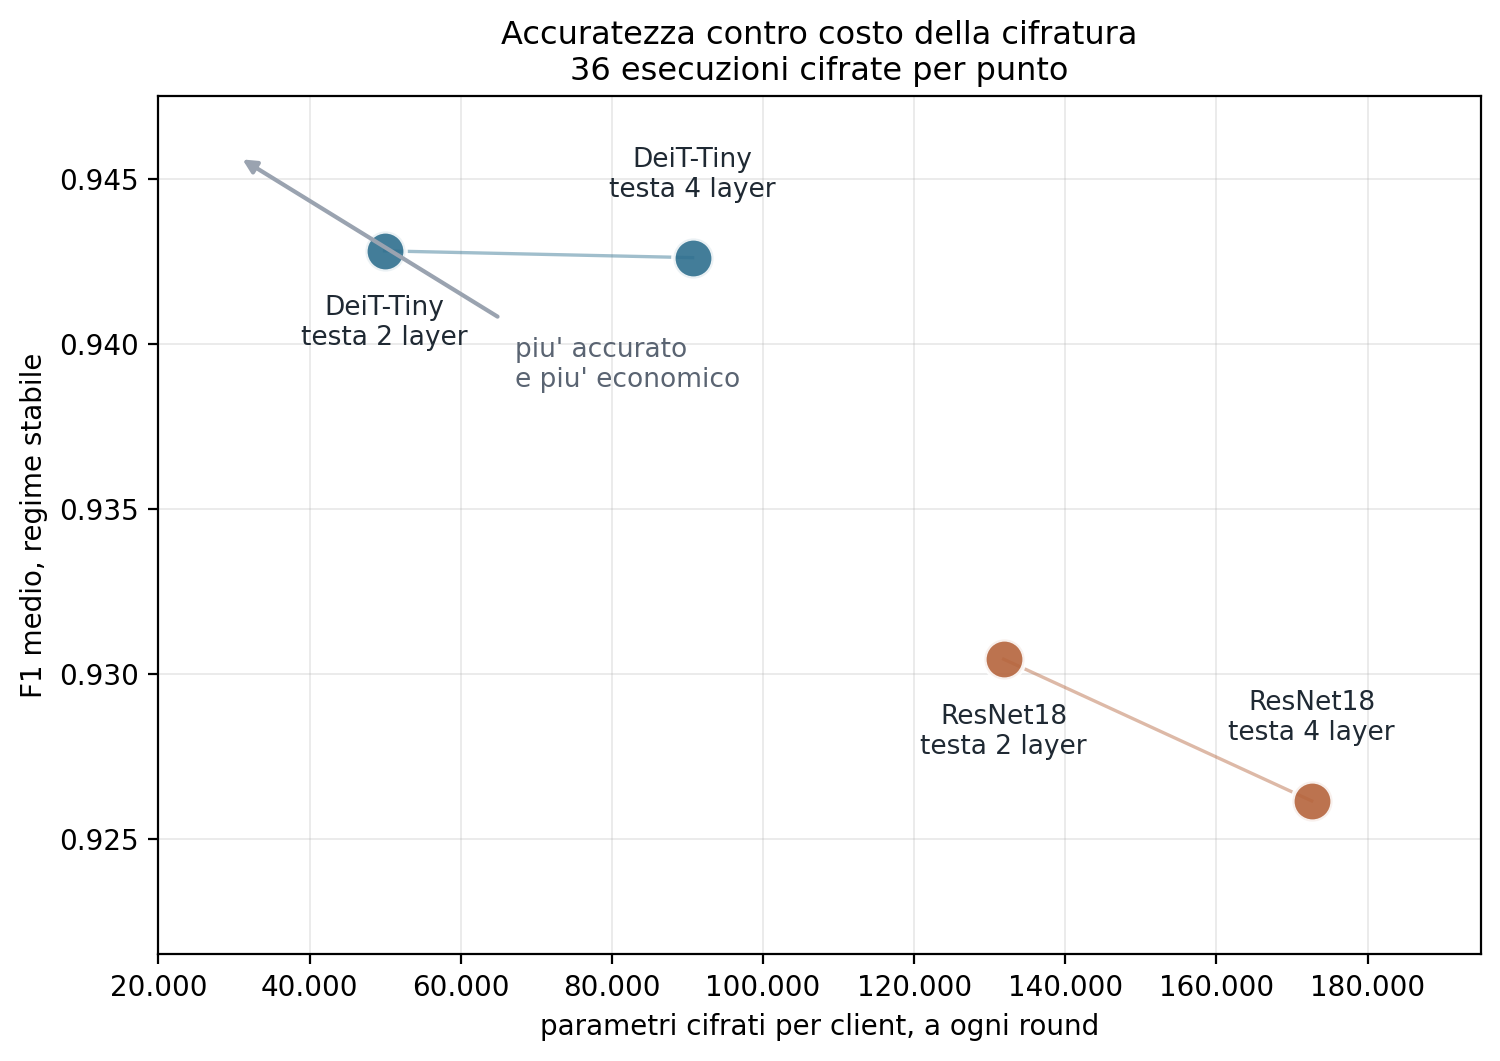

convergenza.png


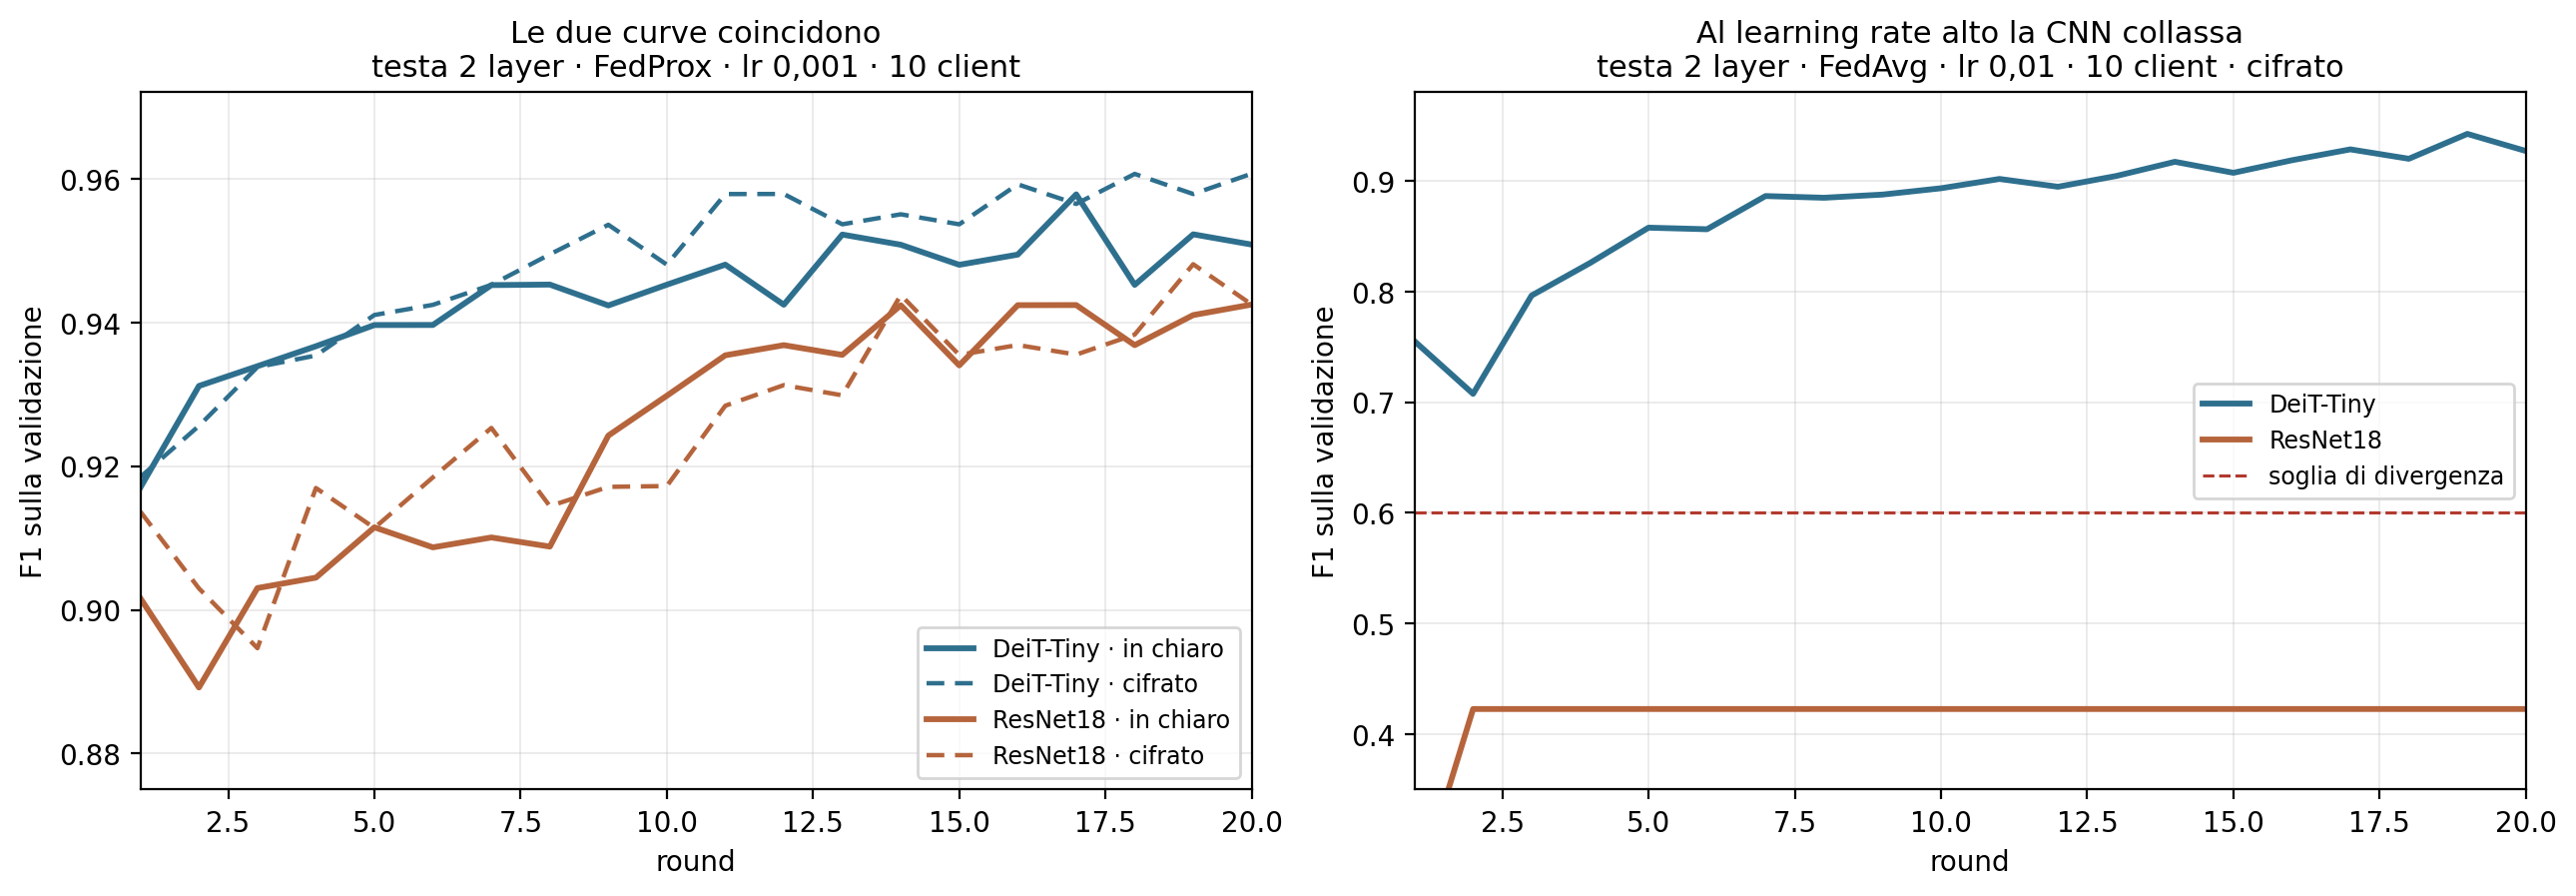

risultati_finali.png


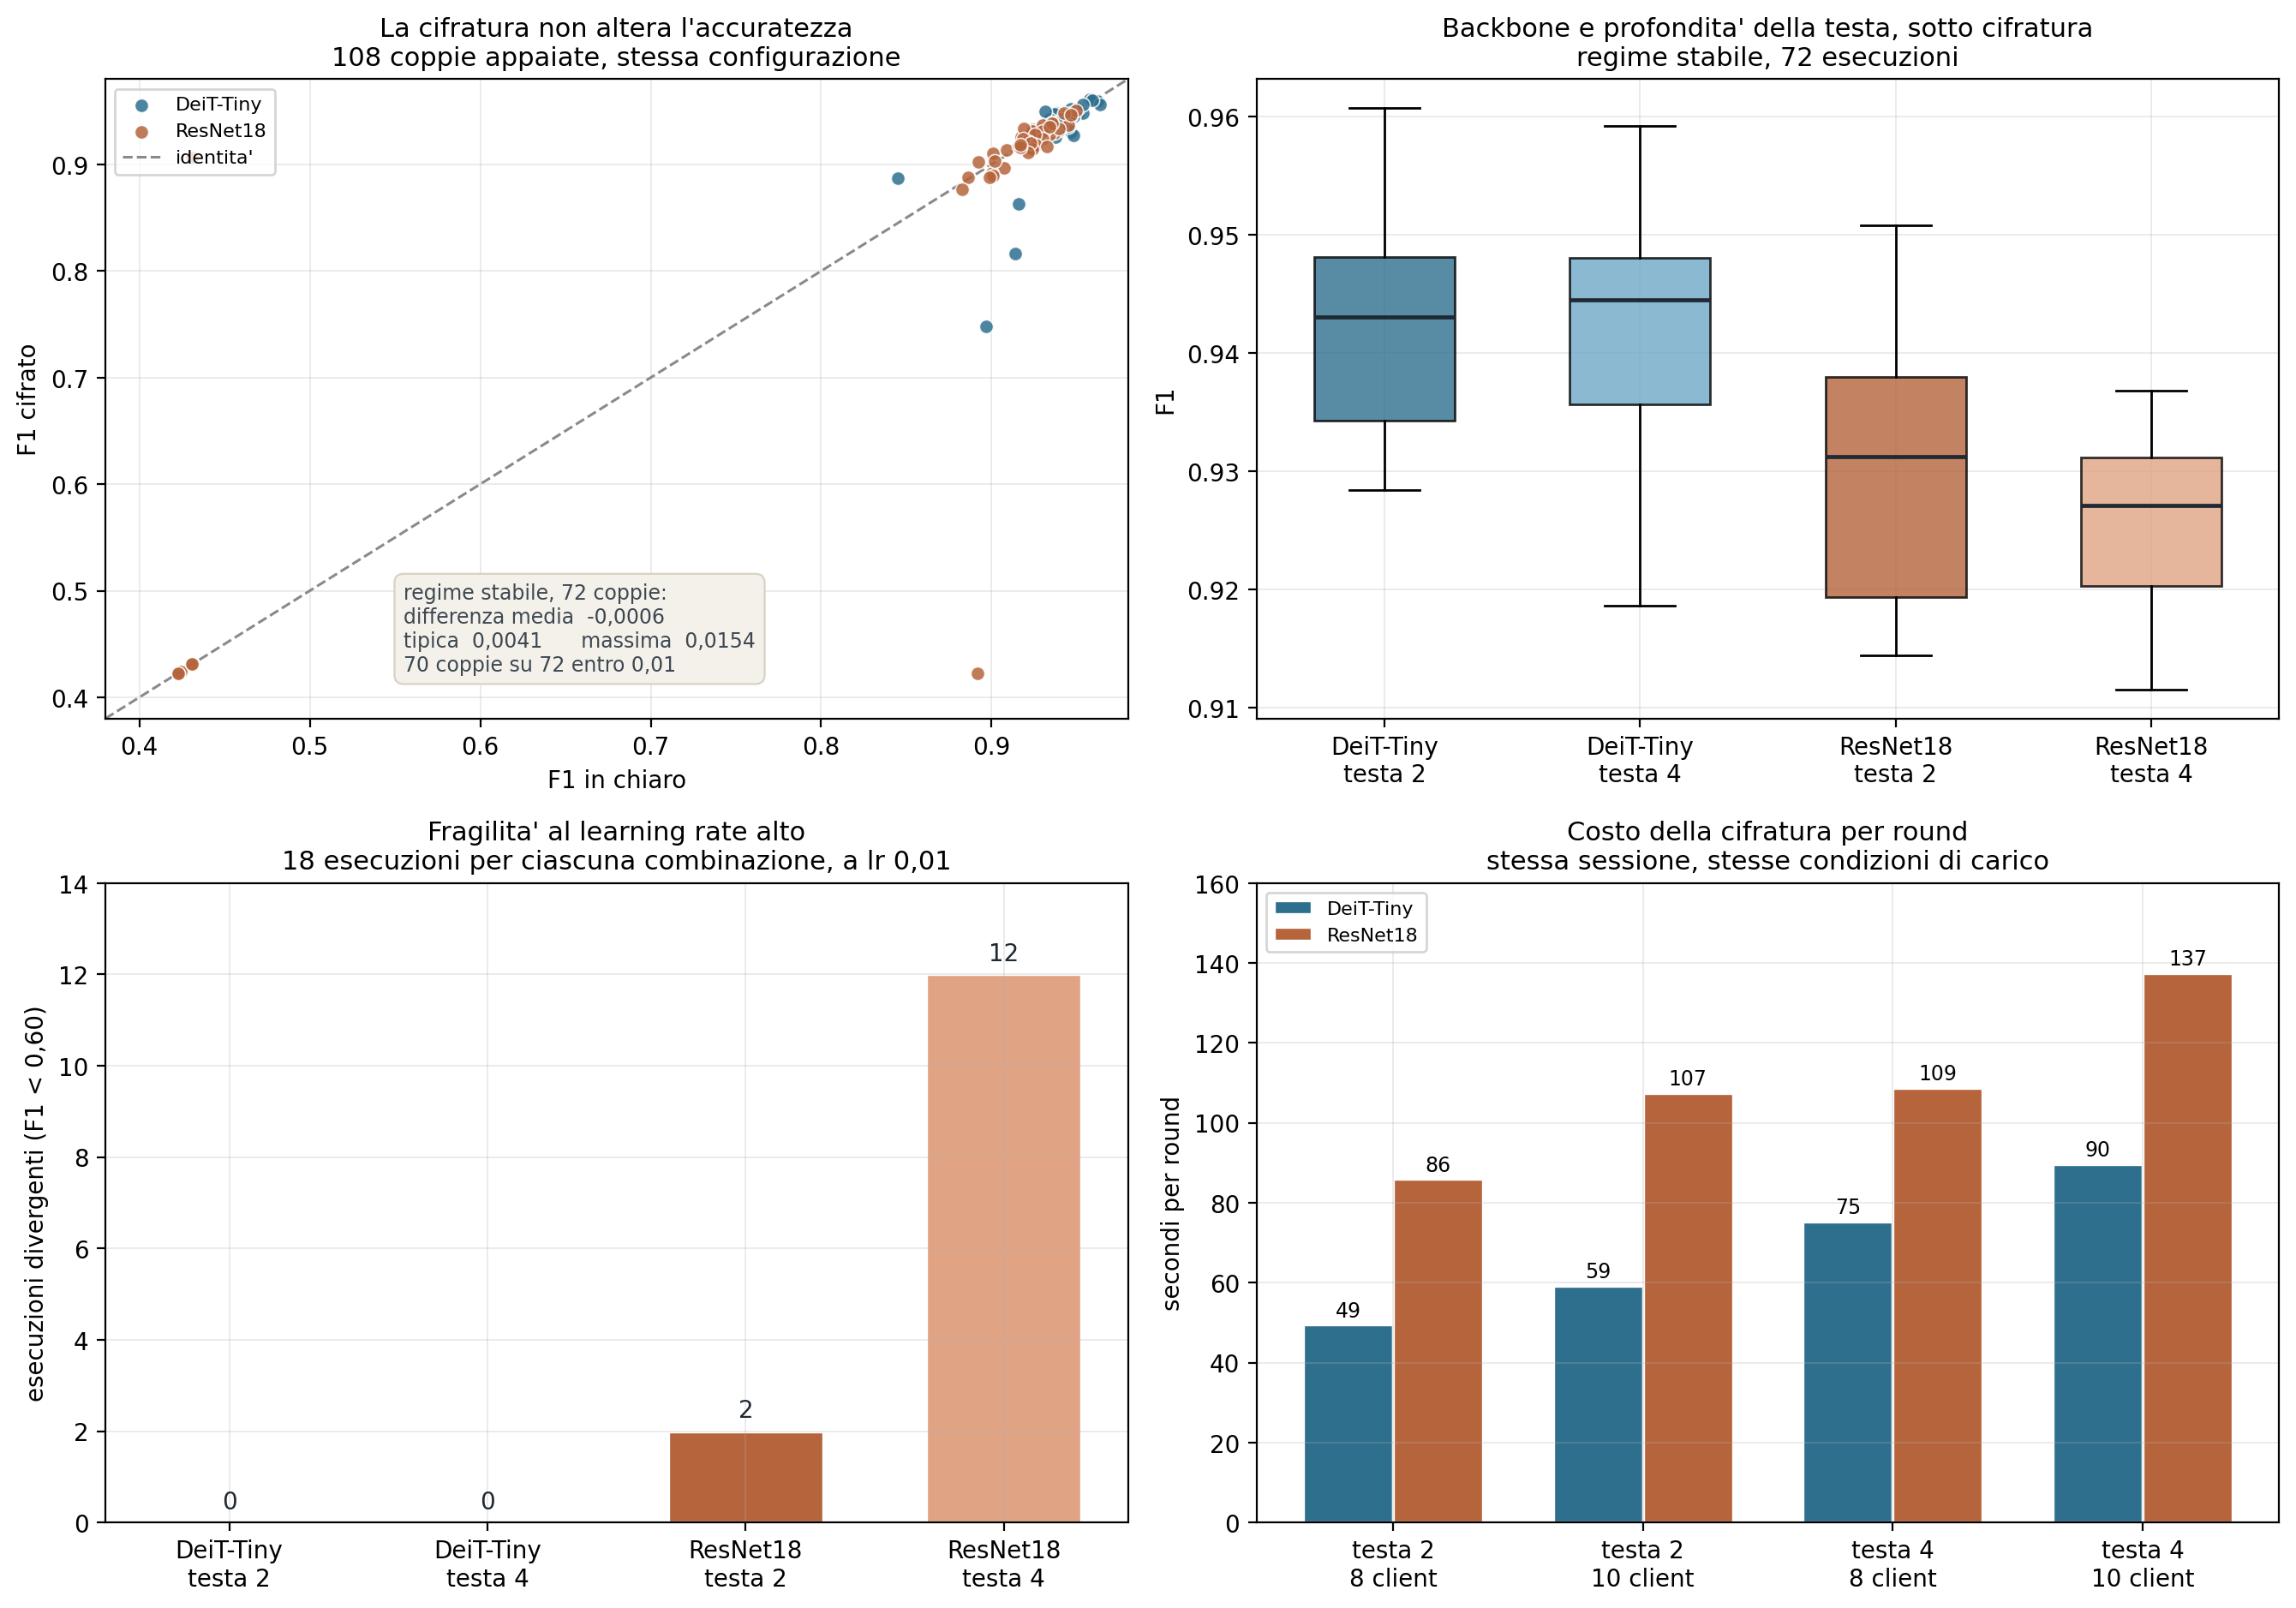

testa2_vs_testa4.png


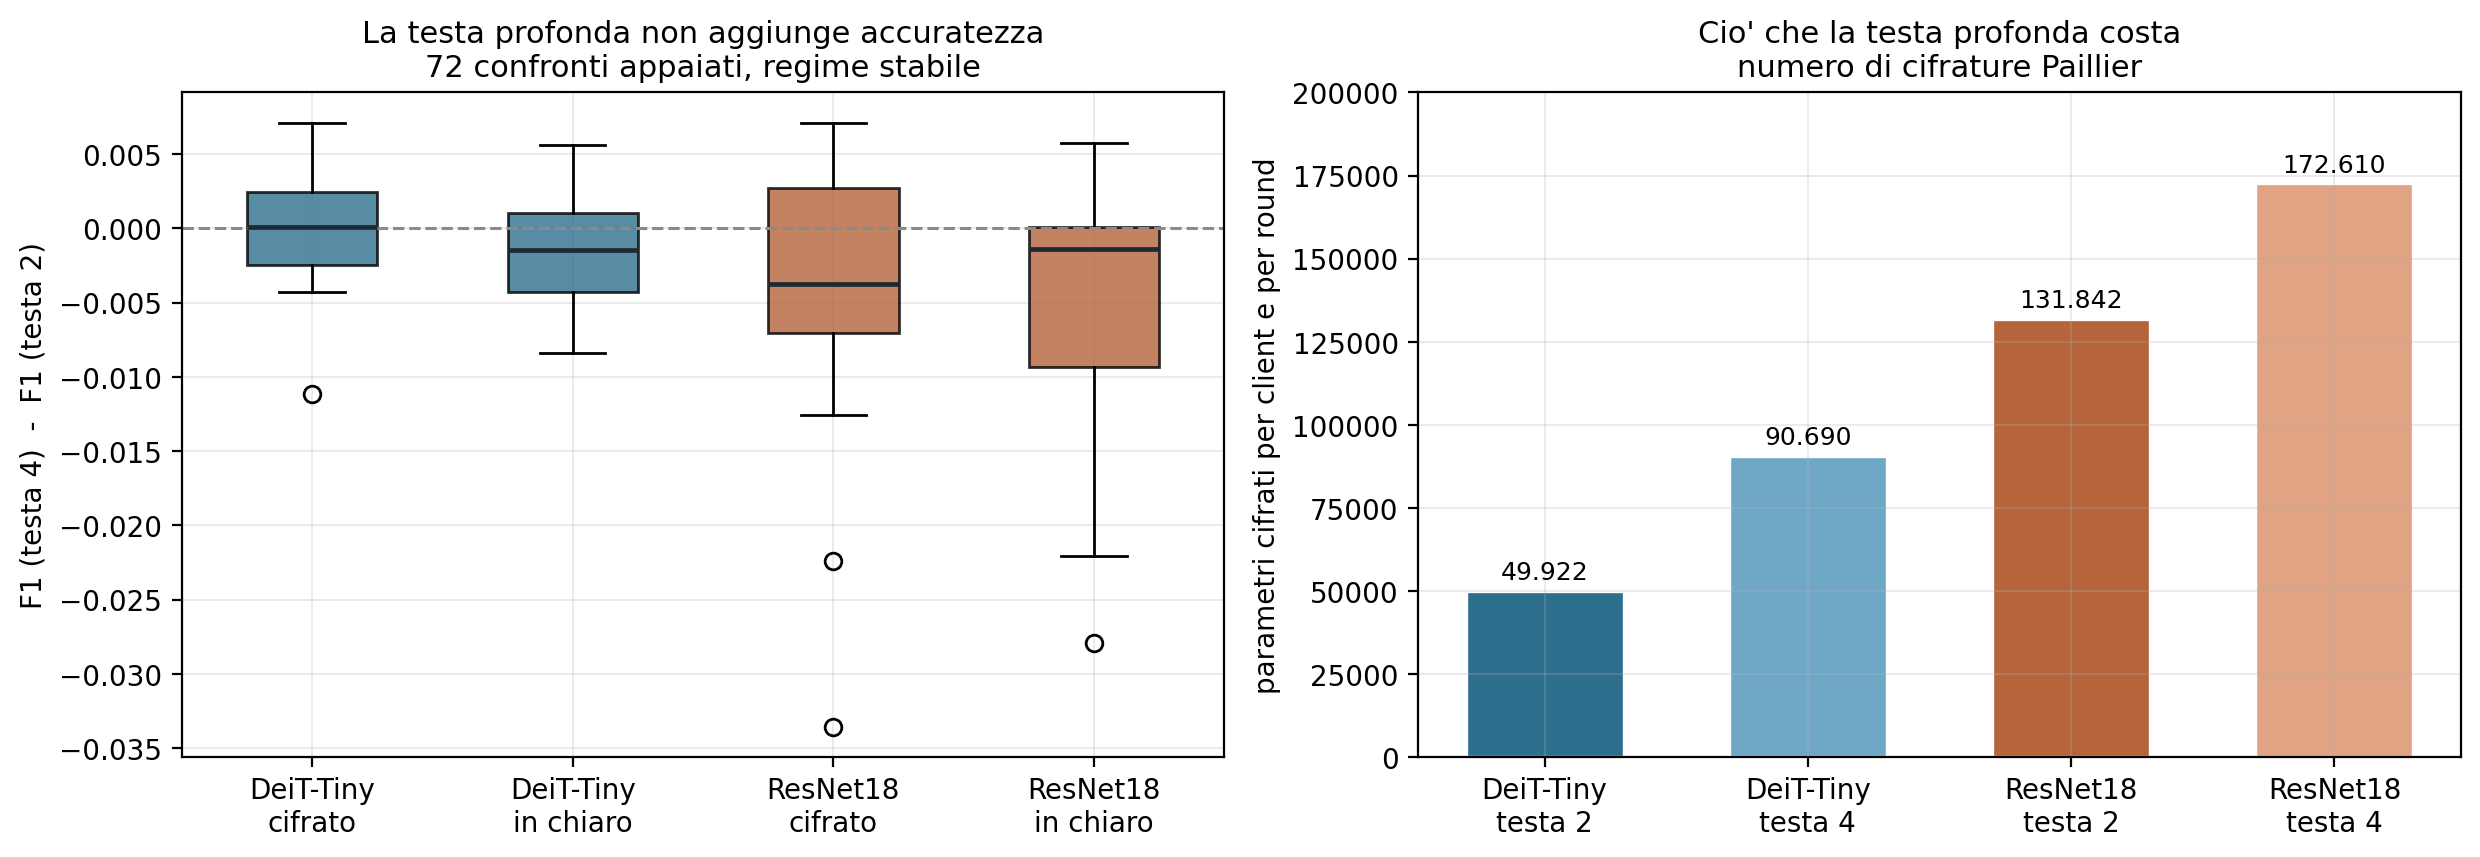

In [ ]:

from IPython.display import Image

esito = subprocess.run([PY, "-u", "figure.py"], cwd=str(CODICE),
                       capture_output=True, text=True)
print(esito.stdout or esito.stderr)

for nome in ("accuratezza_costo.png", "convergenza.png",
             "risultati_finali.png", "testa2_vs_testa4.png"):
    percorso = CODICE / "figure" / nome
    if percorso.exists():
        print(nome)
        display(Image(filename=str(percorso), width=980))